# EDA

## Overview

### Objective

Perform EDA on portfolio and benchmark data to understand volatality, correlations and sector behaviour.

## Loading dataset

In [2]:
import pandas as pd

stocks_df = pd.read_csv("../data/raw/stock_data.csv", sep=",")
benchmark_df = pd.read_csv("../data/raw/benchmark_data.csv", sep=",")
portfolio_df = pd.read_csv("../data/raw/portfolio_holdings.csv", sep=",")

print("=" * 60)
print("Stocks")
display(stocks_df.head(5))
print("=" * 60)
print("Benchmark")
display(benchmark_df.head(5))
print("=" * 60)
print("Portfolio holdings")
display(portfolio_df.head(5))
print("=" * 60)

Stocks


,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-02,AAPL,71.344062,72.394093,71.091191,72.333885,135480400
1,2020-01-03,AAPL,71.563205,72.389257,71.406666,71.630638,146322800
2,2020-01-06,AAPL,70.754021,72.239950,70.503554,72.201416,118387200
3,2020-01-07,AAPL,72.211041,72.466322,71.642681,71.861839,108872000
4,2020-01-08,AAPL,71.565621,73.318877,71.565621,73.017838,132079200


Benchmark


,Date,Open,High,Low,Close,Volume
0,2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3459930000
1,2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3484700000
2,2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3702460000
3,2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3435910000
4,2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3726840000


Portfolio holdings


,Ticker,Shares,Purchase_Price,Purchase_Date
0,AAPL,50,180,2023-05-01
1,MSFT,30,320,2023-06-15
2,NVDA,20,450,2024-01-10
3,JPM,25,180,2023-08-01
4,BAC,40,32,2023-09-15


In [26]:
%run -i "../src/config.py"

## Data Preparation

In [3]:
# converting dates from string to datetime format
stocks_df["Date"] = pd.to_datetime(stocks_df["Date"])
benchmark_df["Date"] = pd.to_datetime(benchmark_df["Date"])

In [4]:
# sorting stocks based upon Ticker, Date
stocks_df = stocks_df.sort_values(["Ticker", "Date"])
benchmark_df = benchmark_df.sort_values("Date")

## Price Trend analysis

### Closing price trends

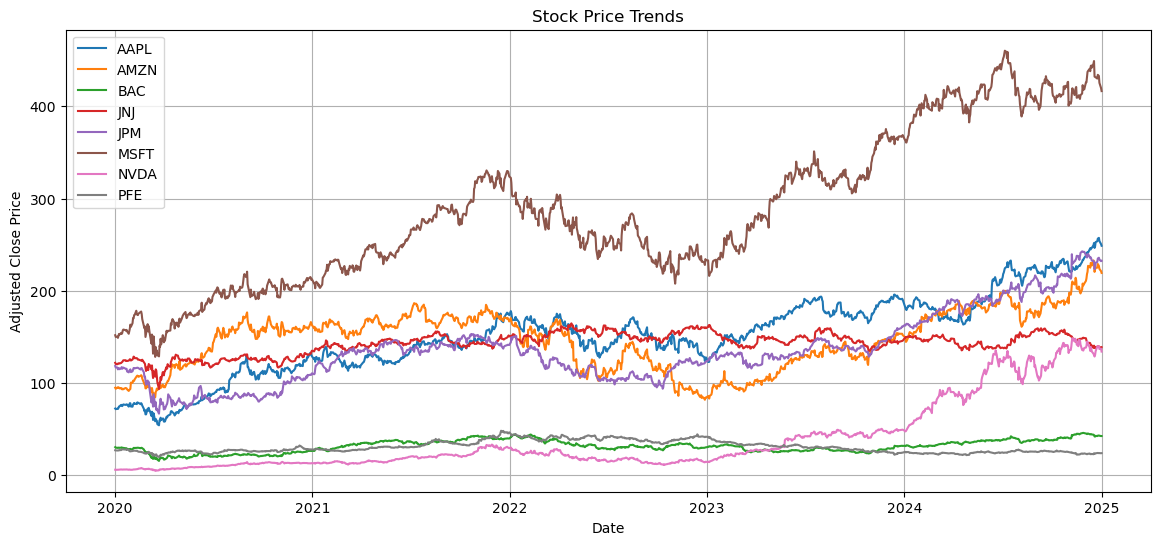

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for ticker in stocks_df["Ticker"].unique():
    data = stocks_df[stocks_df["Ticker"] == ticker]

    plt.plot(data["Date"], data["Close"], label=ticker)

plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [113]:
price_summary = pd.DataFrame()

##### Highest Closing Price

In [114]:
# Highest Closing Price
highest_closing_price_ind = stocks_df.groupby("Ticker")["Close"].idxmax()
highest_closing_price = stocks_df.loc[highest_closing_price_ind, ["Ticker", "Date", "Close"]].rename(columns={"Close": "Highest_Close_Price"})
highest_closing_price.index = highest_closing_price["Ticker"]
del highest_closing_price["Ticker"]
price_summary["Highest_Close_Price"] = highest_closing_price["Highest_Close_Price"]
highest_closing_price

,Date,Highest_Close_Price
Ticker,,
AAPL,2024-12-26,257.375580
AMZN,2024-12-16,232.929993
BAC,2024-11-27,45.930729
JNJ,2022-04-25,164.681686
JPM,2024-11-25,242.758469
MSFT,2024-07-05,460.325592
NVDA,2024-11-07,148.647751
PFE,2021-12-16,48.252922


##### Lowest Closing Price

In [115]:
# Lowest Closing Price
lowest_close_price_id = stocks_df.groupby("Ticker")["Close"].idxmin()
lowest_close_price = stocks_df.loc[lowest_close_price_id, ["Ticker", "Date", "Close"]].rename(columns={"Close": "Lowest_Close_Price"})
lowest_close_price.index = lowest_close_price["Ticker"]
del lowest_close_price["Ticker"]
price_summary["Lowest_Close_Price"] = lowest_close_price["Lowest_Close_Price"]
lowest_close_price

,Date,Lowest_Close_Price
Ticker,,
AAPL,2020-03-23,54.163704
AMZN,2022-12-28,81.820000
BAC,2020-03-23,15.535211
JNJ,2020-03-23,93.433510
JPM,2020-03-23,66.763321
MSFT,2020-03-16,128.358322
NVDA,2020-03-16,4.885129
PFE,2020-03-23,19.889620


##### Appreciation across all years

In [ ]:
# Appreciation across all years 
temp = stocks_df.groupby("Ticker").agg(Start_Price=("Close", "first"), End_Price=("Close", "last"))
price_summary["Start_Price"] = temp["Start_Price"]
price_summary["End_Price"] = temp["End_Price"]
price_summary["Absolute_Gain"] = price_summary["End_Price"] - price_summary["Start_Price"]
price_summary["Price_Appreciation_%"] = (price_summary["Absolute_Gain"] / price_summary["Start_Price"]) * 100

##### CAGR

In [121]:
# Annual Growth Rate (CAGR)
no_of_years = int(END_DATE.split("-")[0]) - int(START_DATE.split("-")[0]) + 1
price_summary["CAGR"] = ((price_summary["End_Price"] / price_summary["Start_Price"])**(1/no_of_years)) - 1
price_summary["CAGR"]

Ticker
AAPL    0.228646
AMZN    0.149895
BAC     0.057232
JNJ     0.021804
JPM     0.118989
MSFT    0.183187
NVDA    0.680011
PFE    -0.020159
Name: CAGR, dtype: float64

In [122]:
price_summary = price_summary.sort_values("Price_Appreciation_%", ascending=False)
price_summary

,Highest_Close_Price,Lowest_Close_Price,Start_Price,End_Price,Absolute_Gain,Price_Appreciation_%,CAGR
Ticker,,,,,,,
NVDA,148.647751,4.885129,5.963804,134.089752,128.125948,2148.393096,0.680011
AAPL,257.375580,54.163704,72.333885,248.830200,176.496315,244.002261,0.228646
MSFT,460.325592,128.358322,151.829559,416.558441,264.728882,174.359251,0.183187
AMZN,232.929993,81.820000,94.900497,219.389999,124.489502,131.178977,0.149895
JPM,242.758469,66.763321,118.430313,232.496826,114.066513,96.315301,0.118989
BAC,45.930729,15.535211,30.429451,42.492878,12.063427,39.643919,0.057232
JNJ,164.681686,93.433510,121.936943,138.784348,16.847404,13.816489,0.021804
PFE,48.252922,19.889620,27.048365,23.937206,-3.111158,-11.502205,-0.020159


##### Conclusions

- **Which stock experienced strongest growth?**  
Nvidia was the best performing stock, corresponding to CAGR of 68%.

- **Which stock stagnated/performed poorly?**  
Pfizer showed the weakest performance, recording a negative price appreciation of 11.5% and negative CAGR of 2.02%.  
Johnson & Johnson also demonstrated relatively stagnant growth.

### Indexed Growth Comparison

##### Normalization of every stock to 100

In [128]:
norm_stocks_df = stocks_df.copy()
norm_stocks_df["Normalized_Price"] = norm_stocks_df.groupby("Ticker")["Close"].transform(lambda x: (x / x.iloc[0]) * 100)
norm_stocks_df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Normalized_Price
0,2020-01-02,AAPL,71.344062,72.394093,71.091191,72.333885,135480400,100.000000
1,2020-01-03,AAPL,71.563205,72.389257,71.406666,71.630638,146322800,99.027776
2,2020-01-06,AAPL,70.754021,72.239950,70.503554,72.201416,118387200,99.816864
3,2020-01-07,AAPL,72.211041,72.466322,71.642681,71.861839,108872000,99.347407
4,2020-01-08,AAPL,71.565621,73.318877,71.565621,73.017838,132079200,100.945549


##### Growth of $100 invested

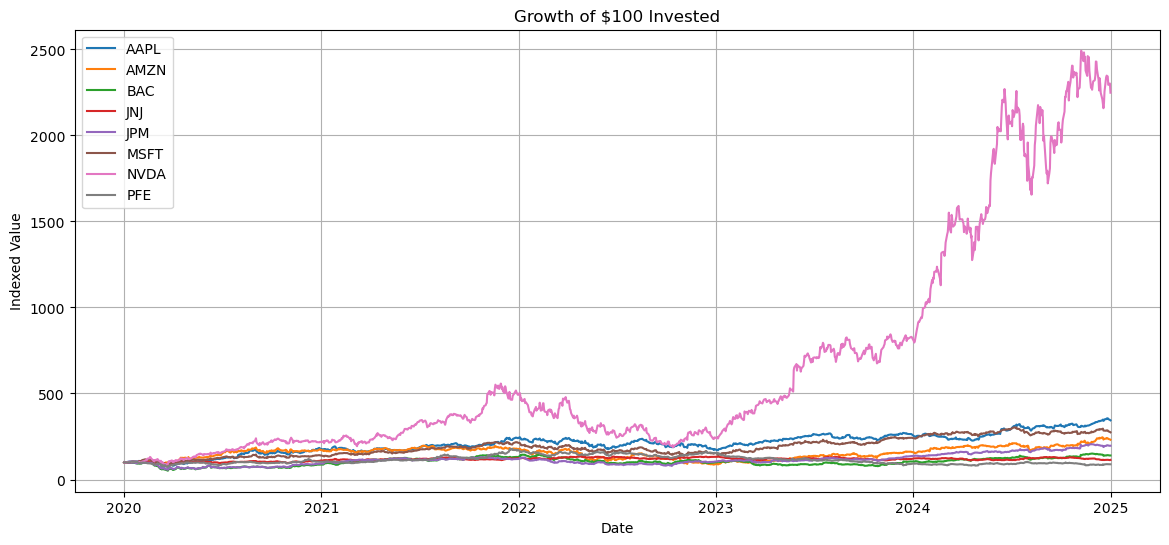

In [132]:
plt.figure(figsize=(14, 6))

for ticker in norm_stocks_df["Ticker"].unique():
    temp = norm_stocks_df[norm_stocks_df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["Normalized_Price"], label=ticker)

plt.title("Growth of $100 Invested")
plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.legend()
plt.grid(True)
plt.show()

##### Investment performance

In [134]:
investment_summary = norm_stocks_df.groupby("Ticker").agg(Final_Investment_Value=("Normalized_Price", "last"))
investment_summary["Investment_Gain"] = investment_summary["Final_Investment_Value"] - 100
investment_summary = investment_summary.sort_values("Investment_Gain", ascending=False)
investment_summary

,Final_Investment_Value,Investment_Gain
Ticker,,
NVDA,2248.393096,2148.393096
AAPL,344.002261,244.002261
MSFT,274.359251,174.359251
AMZN,231.178977,131.178977
JPM,196.315301,96.315301
BAC,139.643919,39.643919
JNJ,113.816489,13.816489
PFE,88.497795,-11.502205


##### Conclusions

- **If $100 were invested in each stock, which produced the highest wealth?**  
Nvidia - \$100 became \$2248.39

- **Which stock destroyed value?**  
Pfizer